# 準備（データの読み込み、特徴把握）

・みんなのKaggle講座と合併して復習。
・ダミー変数は使ってない。Randomforestの分岐はいじった。
・


In [2]:
%config Completer.use_jedi = False

In [3]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# データの読み込み
data_trained = pd.read_csv('/kaggle/input/titanic/train.csv')
data_test = pd.read_csv('/kaggle/input/titanic/test.csv')
data_gender_submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

## 特徴量エンジニアリング
文字列を数値に置き換え
欠損値の扱い

In [19]:
# 教師データとテストデータ双方にエンジニアリングを行うため、結合
data_all = pd.concat([data_trained, data_test], sort = False) # 列の順番は変えずにただ結合してください

### 指針
1. 女性の方が生存率が高い → 男性と女性で特徴量を分けてみる
2. ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量を作ってみる
3. Ageは範囲が広いし、Missingも多い。平均で補完が不正確か。→ 中央値、あるいは平均±標準偏差の中からのランダム値で


In [20]:
# 各特徴量の欠損値の数を確認
# データの欠損は　isnull
# TestデータはSurvivedがないので欠損値扱い

data_all.isnull().sum()

# Null418件がテストデータの数を意味する

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [21]:
# Sexの値を男性と女性で分ける
# 同じ特徴量で傾向が大きく違うのであれば、特徴量を分けることで正確に反映し精度が上がるという考え方
# 列を追加
data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
data_all['Sex'] = data_all['Sex'].replace(['female', 'male'], [1, 0])# 既存についても変換
data_all.head()

/tmp/ipykernel_17/1147175446.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
/tmp/ipykernel_17/1147175446.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
/tmp/ipykernel_17/1147175446.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0


<Axes: xlabel='Families', ylabel='count'>

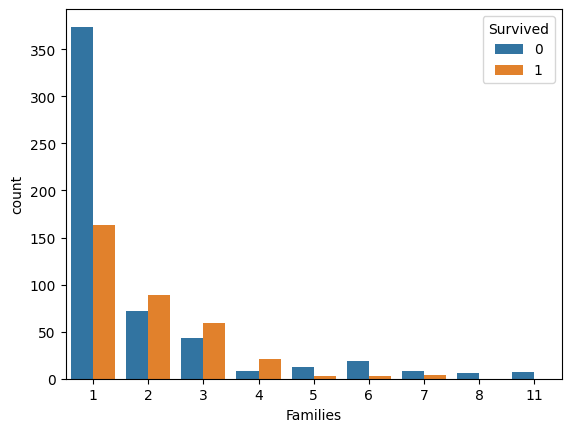

In [22]:
# ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量Familiesを作ってみる
data_all['Families'] = data_all['Parch'] + data_all['SibSp'] + 1
# 教師データの傾向を見るため、一時的にテストデータと分離
data_trained['Families'] = data_all['Families'][:len(data_trained)] # 教師データの件数分まで
data_test['Families'] = data_all['Families'][len(data_trained):] # 教師データの件数分以降

sns.countplot(x = 'Families', data = data_trained, hue = 'Survived')
# 単身者は0になるので、＋1で1人という情報を与える　
# Families で最後に＋1すると、単身者と、配偶者や子供や兄弟が一人いた人とが区別つかなくならない？）いっか、全てに＋1してるから、全体的に右によるだけで武ｂｂぷは変わらない


In [23]:
# 単身者は多すぎるので、別の特徴量として抜き出す
data_all['Alone'] = 0
data_all.loc[data_all['Families'] == 1, 'Alone'] = 1 # loc で行データの書き換え。Familiesが1（独り身）に対して、Aloneに1を入れる。
data_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0,1,1


In [24]:
# Embarkedの欠損値を補完する、数値に置き換える
    # 2件でも欠損があればアルゴリズムは適応できないから
    # 本来なら欠損値を補完する方法を検討するが、今回は2件だし一番多いSで補完
data_all['Embarked'].fillna('S', inplace = True)
data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ
data_all.head(900)

# One-Hotエンコーディング
    # Embarkedを1、2、3で置き換えると、その大きさに意味があるものとアルゴリズムに勘違いされてしまう場合がある。ので、データの数分、列数が増えるので、データサイズが大きくなる。
    # カテゴリ指定を予めできるものもあり、数値特有の大きさや順番を考慮しないものもある

# get_dummies()を使う(テキスト化解いただけだと動かないから注意)
    # cat_label = ['Sex', 'Pclass', 'Embarked']  # カテゴリ変数のラベルを指定
    # data_trained = pd.get_dummies(data_trained, columns = cat_labels)
    # data_test = pd.get_dummies(test_data, columns = cat_labels)

/tmp/ipykernel_17/3190637180.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Embarked'].fillna('S', inplace = True)
/tmp/ipykernel_17/3190637180.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0,0,1,3,0
5,897,NaN,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0,1,0,1,1
6,898,NaN,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2,0,1,1,1
7,899,NaN,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0,1,0,3,0


In [25]:
# Fareは平均で補完。
# Ageは、平均±標準偏差の中からのランダム値で補完
data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)

ave = data_all['Age'].mean()
std = data_all['Age'].std()
data_all['Age'].fillna(np.random.randint(ave - std, ave + std), inplace = True)
# 乱数なので再現性はないし、年齢および欠損値が正規分布に従っていると仮定しているが、中央値も手
# data_all['Age'].fillna(data_all['Age'].median(), inplace = True)
    
data_all.head()

/tmp/ipykernel_17/4048252845.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)
/tmp/ipykernel_17/4048252845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1


In [26]:
# 影響のないあるいは少なそうな特徴量については一旦削除。
# drop 行または列で削除する関数。axis - 1で列方向
drop_colums = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data_all.drop(drop_colums, axis = 1, inplace = True)
data_all.isnull().sum()
# まあこれでひとまず欠損値はなくなった
# SibSpやらParchは消していいのか？

Survived      418
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Sex_male        0
Sex_female      0
Families        0
Alone           0
dtype: int64

In [27]:
# 結合したデータを、再度、教師データと、テストデータに分ける
# len関数は、行数を返してくれる。スライスで該当行を抜き出し。（0：　が省略されてる）
# 先頭行から教師データの件数だけ抜き出すのと、その一個下のデータから
data_trained = data_all[:len(data_trained)]
data_test = data_all[len(data_trained):]

## モデル作成

アルゴリズム…数値に対する演算をまとめたもの。決定木をベースに拡張。一つの特徴量ごとに閾値（条件判定の結果の値）を決めて、処理を分岐させてこの分岐ならこの予測値、を出す。

ランダムフォレストは複数の学習機の結果をもとに予測を出す。例えばGenderを最初にした決定木の予測では不十分なので、複数の決定木を組み合わせたアンサンブル学習から精度を高める。例えば多数決を取るなど。

In [28]:
# アルゴリズムに投入用意。多くの場合別々に投入するのでそのために特徴量と目的変数を分離、x,yと頭文字をつけておく
y_data_trained = data_trained['Survived'] # 目的変数を格納。教師データ
x_data_trained = data_trained.drop('Survived', axis = 1) # 説明変数を格納、dropで目的変数’Survived’は削除。axis = 1は列を削除の意味
x_data_test = data_test.drop('Survived', axis = 1) # testデータにはSurvivedがなかったが、結合で列が発生したので消しておく。

In [29]:
#SVC アルゴリズムをインポート
    
from sklearn.svm import SVC

sv = SVC(kernel = 'rbf', C = 1.0, gamma = 'scale') # rbf　非線形分離のデータに強い

# fit 教師データに適用して、学習させる
sv.fit(x_data_trained, y_data_trained) # 説明変数と目的変数を別の変数として指定

SVC()

In [30]:
y_data_pred = sv.predict(x_data_test)# 学習したclfに対して、引数にはテストデータを指定
# predictの閾値はデフォルト0.5。それ未満を0、以上を1として丸めて返す。本来0〜1の確率として返す。生存確率が高い0.5以上を生存、未満を0の死亡と返す。
y_data_pred
# Survivedに対する予測結果。テストデータとして与えた先頭行の乗船客から順に予測が行われリストが返される。

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0.

## Submit

In [31]:
# 予測結果をSubmit用のCSVファイルとして作成
submit = data_gender_submission # 冒頭で作った変数。提出用CSVのこと。めんどいのでsubmitとする。
submit['Survived'] = list(map(int, y_data_pred)) 
# map 指定した要素に対して、適用したい関数（int）を適用できる関数。予測結果を整数型にして提出フォーマットに合わせるため。
# リストで提出用ファイルに.
submit.to_csv('randomforest_reenginerring_submit.csv', index = False) # 出力ファイル名,index番号は出力しない

submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
